# 01 · Exploratory Data Analysis

Profiling the Spotify Hit Predictor data (1960–2019) before modelling: summary statistics, class balance, how features separate hits from flops, correlations, and how feature averages drift across eras.

In [1]:
import pandas as pd
from IPython.display import Image, display
pd.set_option('display.precision', 3)
desc = pd.read_csv('../results/eda_descriptive_stats.csv', index_col=0)
byc  = pd.read_csv('../results/eda_by_class_means.csv', index_col=0)
print('Loaded descriptive stats for', len(desc), 'features')

Loaded descriptive stats for 15 features


## Descriptive statistics (all 41,103 tracks)

In [2]:
display(desc[['mean','std','min','50%','max']])

,mean,std,min,50%,max
danceability,0.540,0.178,0.058,0.552,9.880e-01
energy,0.580,0.253,0.000,0.601,1.000e+00
key,5.213,3.535,0.000,5.000,1.100e+01
loudness,-10.221,5.311,-49.253,-9.257,3.744e+00
mode,0.693,0.461,0.000,1.000,1.000e+00
speechiness,0.073,0.086,0.022,0.043,9.600e-01
acousticness,0.364,0.339,0.000,0.258,9.960e-01
instrumentalness,0.154,0.304,0.000,0.000,1.000e+00
liveness,0.202,0.173,0.013,0.132,9.990e-01
valence,0.542,0.267,0.000,0.559,9.960e-01


## Class balance by decade
Each decade is sampled 50/50 hit/flop, so accuracy is read against a 50% baseline.

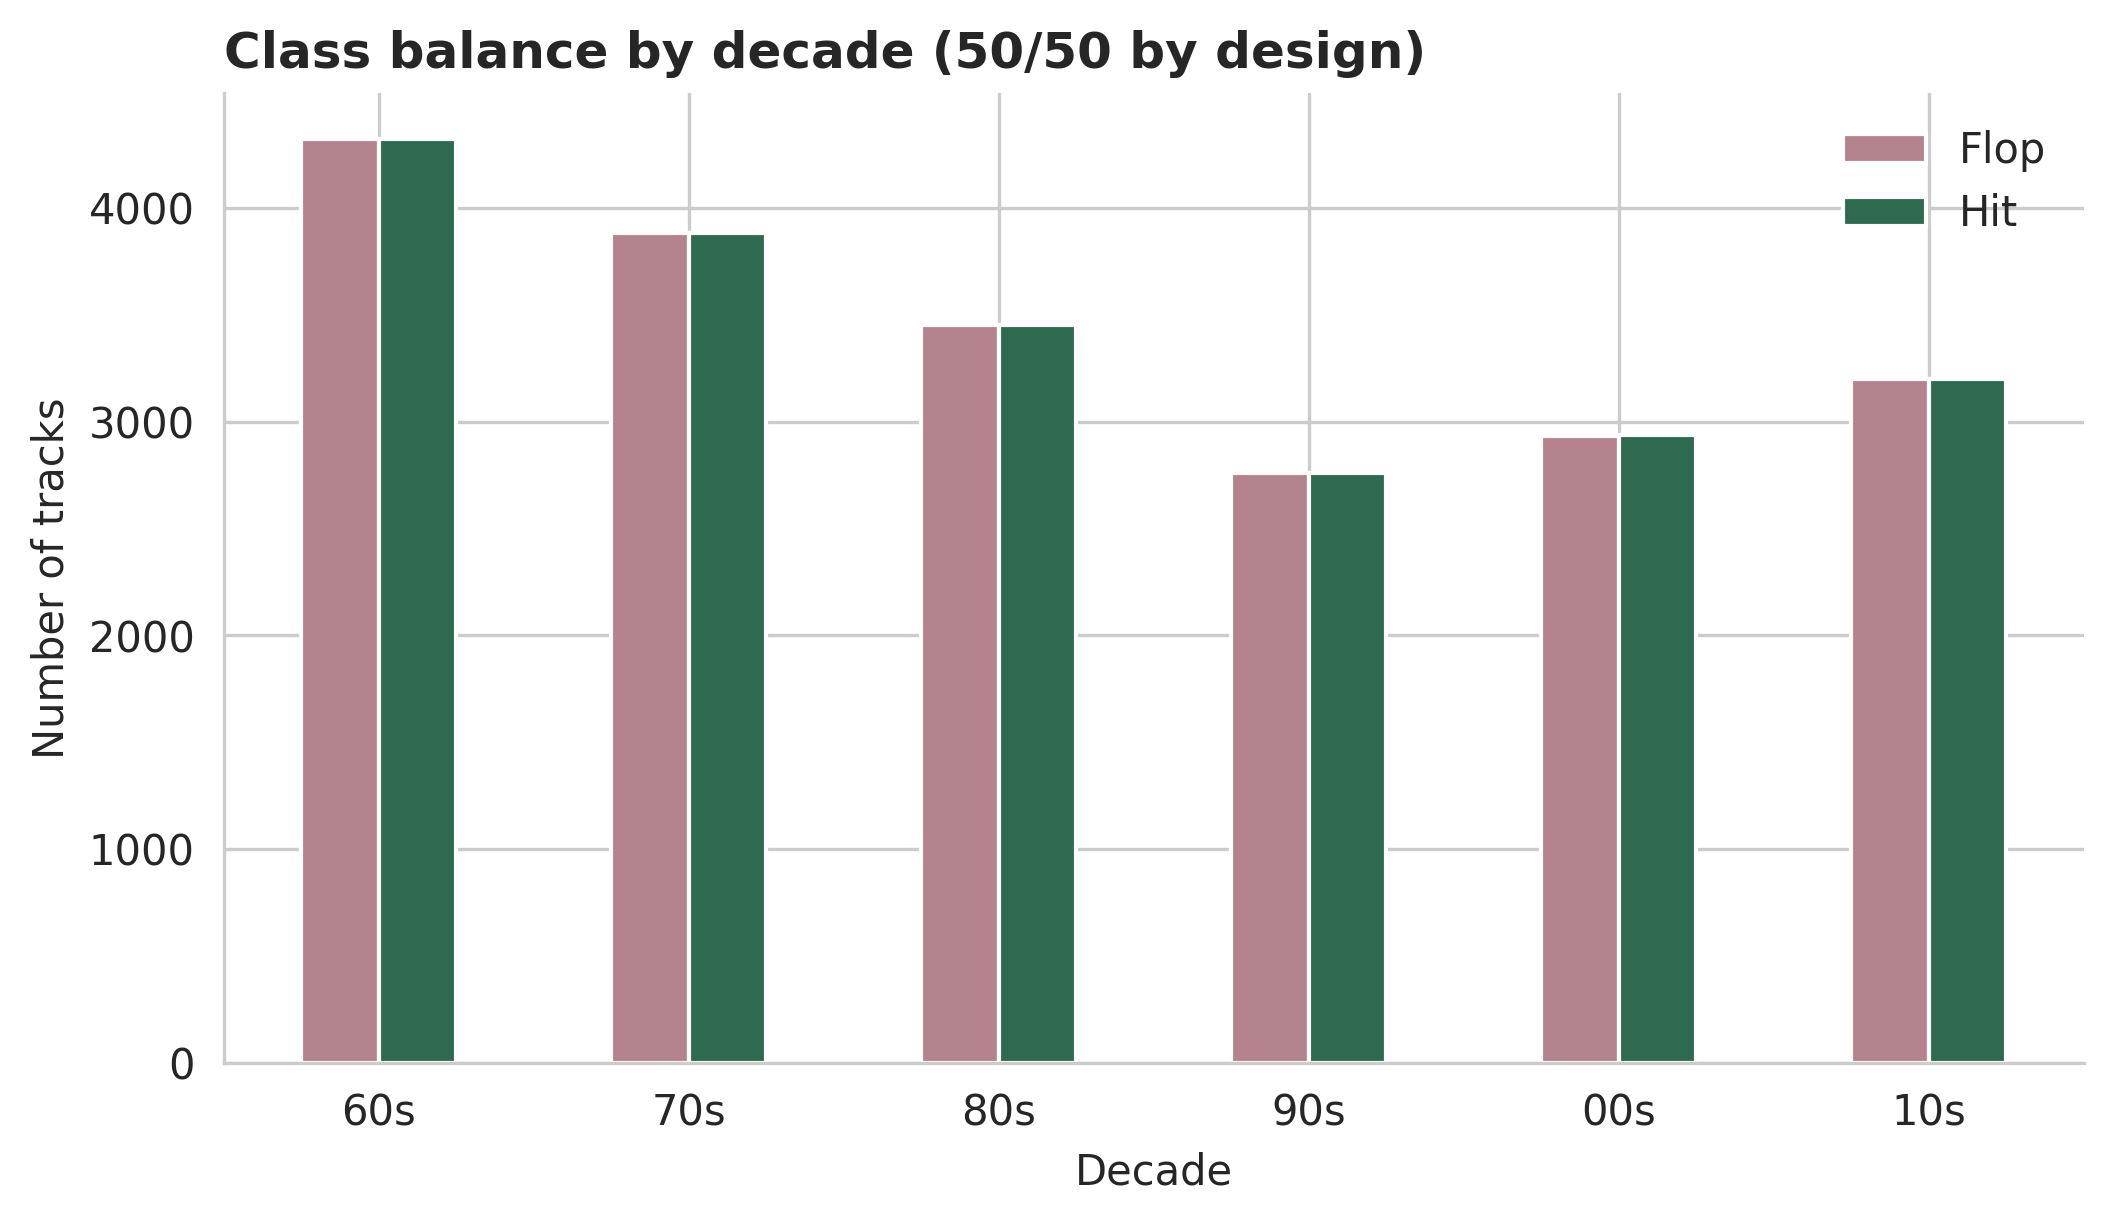

In [3]:
display(Image('../figures/eda1_class_balance.png'))

## How features separate hits from flops
Hits are louder, far less instrumental, less acoustic, and more positive (higher valence).

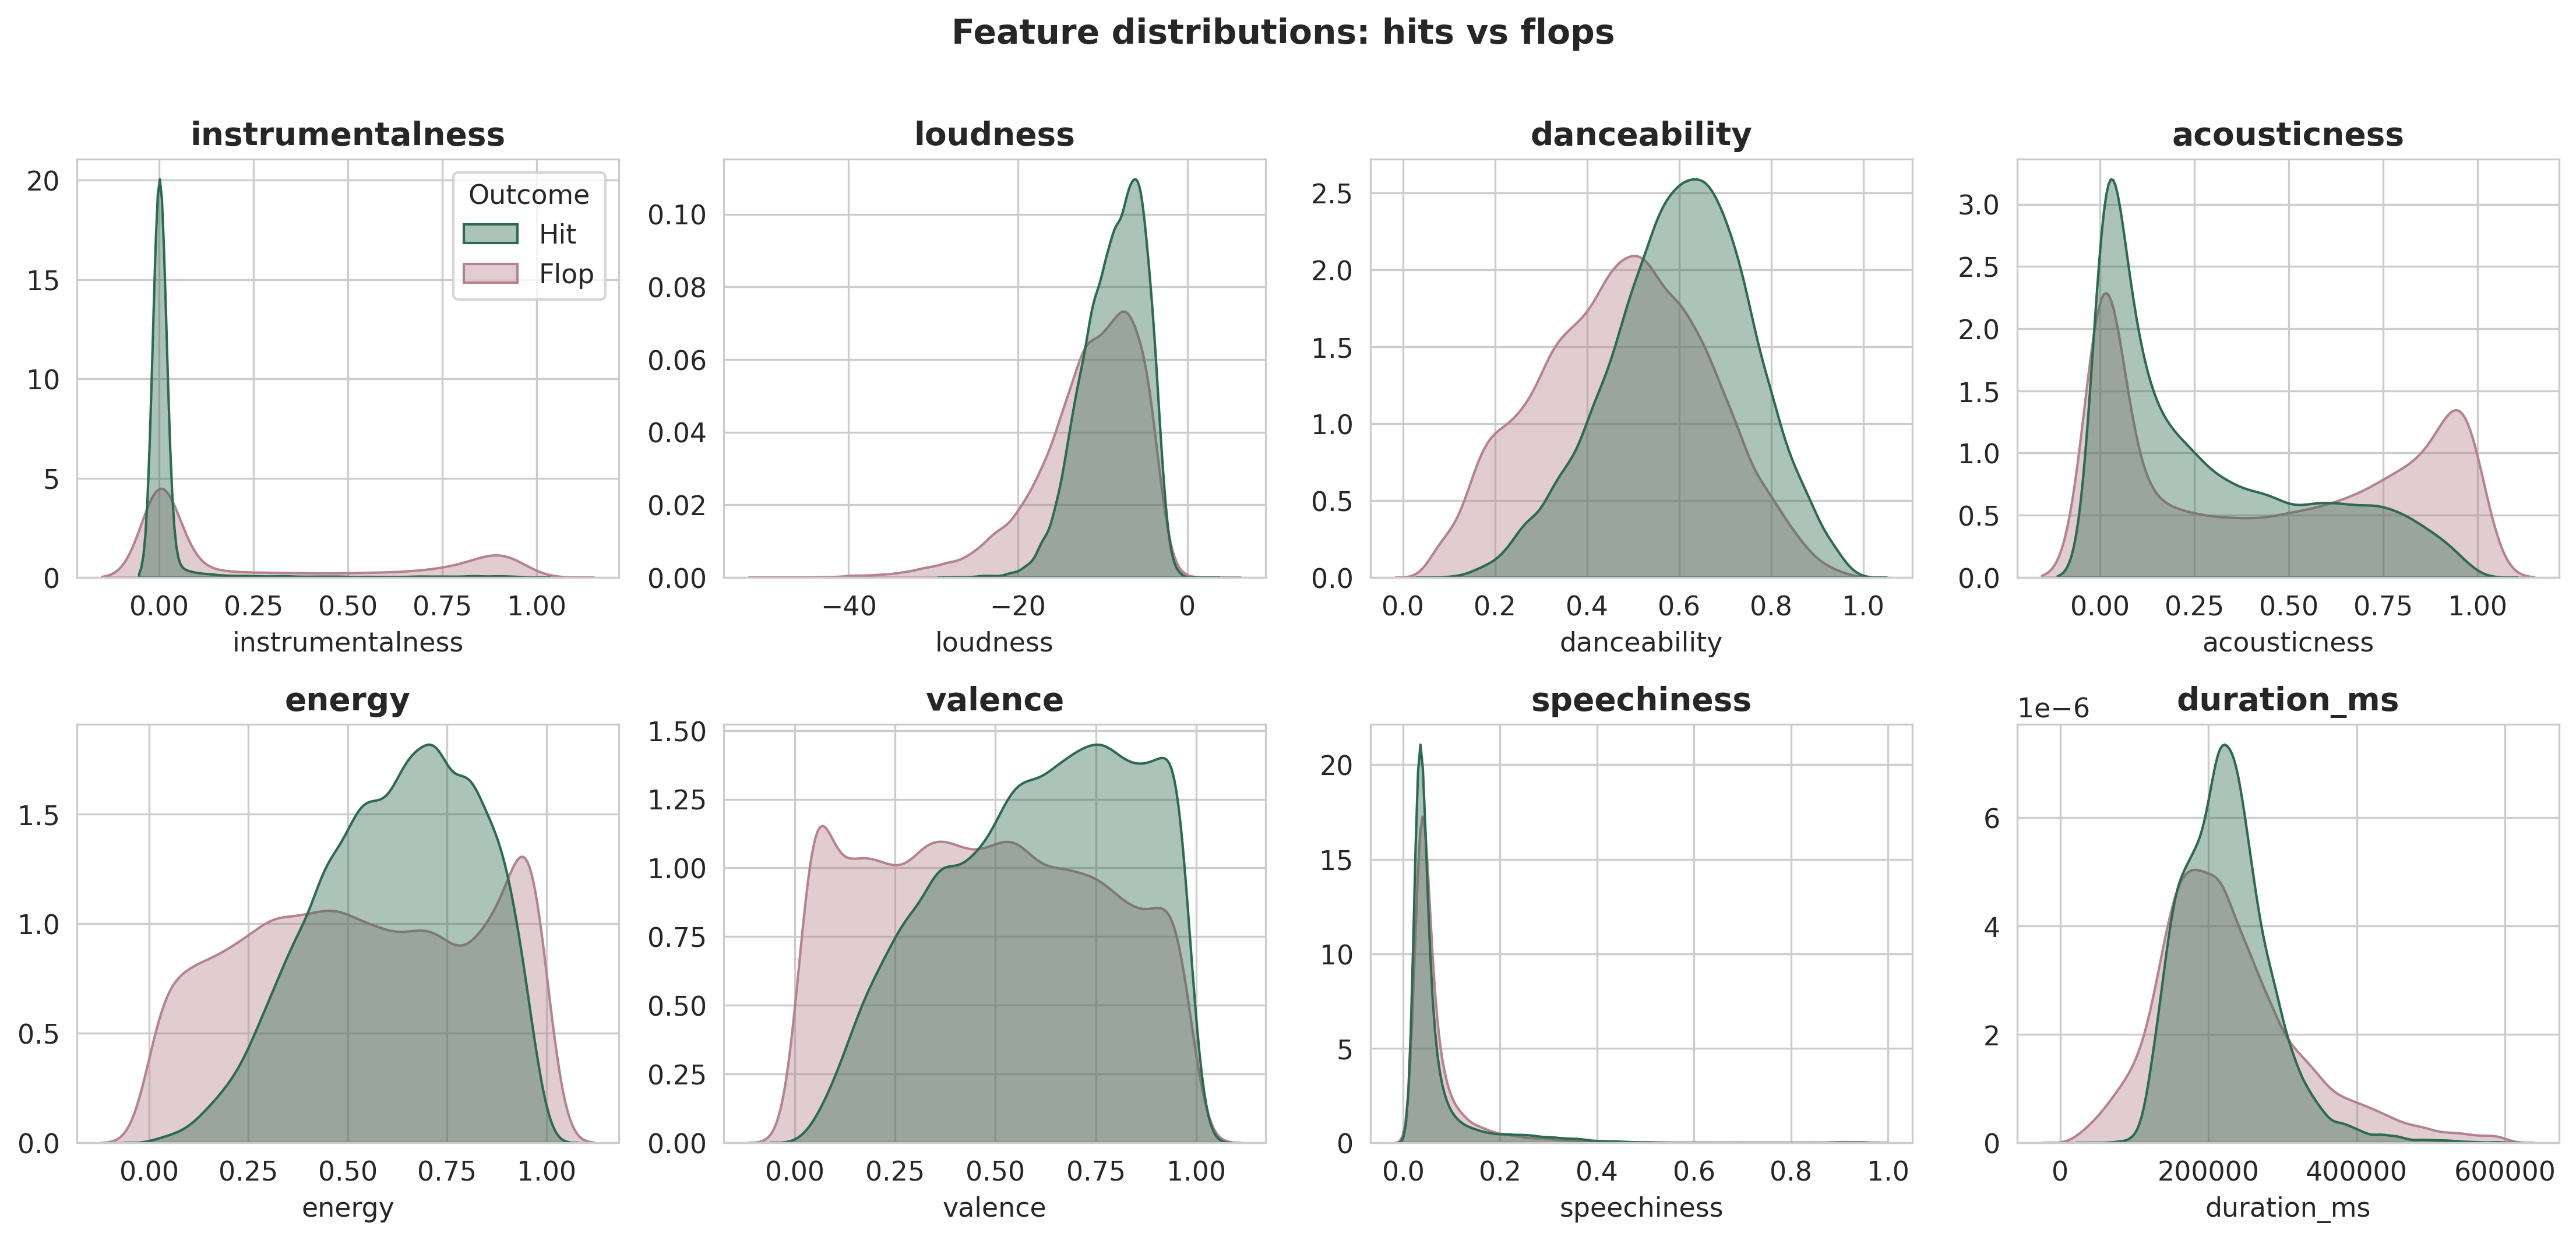

,flop_mean,hit_mean,hit_minus_flop
duration_ms,243663.097,226097.857,-17565.239
loudness,-11.740,-8.702,3.038
tempo,118.392,120.294,1.902
chorus_hit,40.983,39.225,-1.759
sections,10.768,10.184,-0.585
instrumentalness,0.278,0.031,-0.247
acousticness,0.448,0.281,-0.167
valence,0.475,0.610,0.134
danceability,0.478,0.601,0.123
energy,0.535,0.624,0.090


In [4]:
display(Image('../figures/eda2_feature_distributions.png'))
display(byc.reindex(byc['hit_minus_flop'].abs().sort_values(ascending=False).index))

## Feature correlations

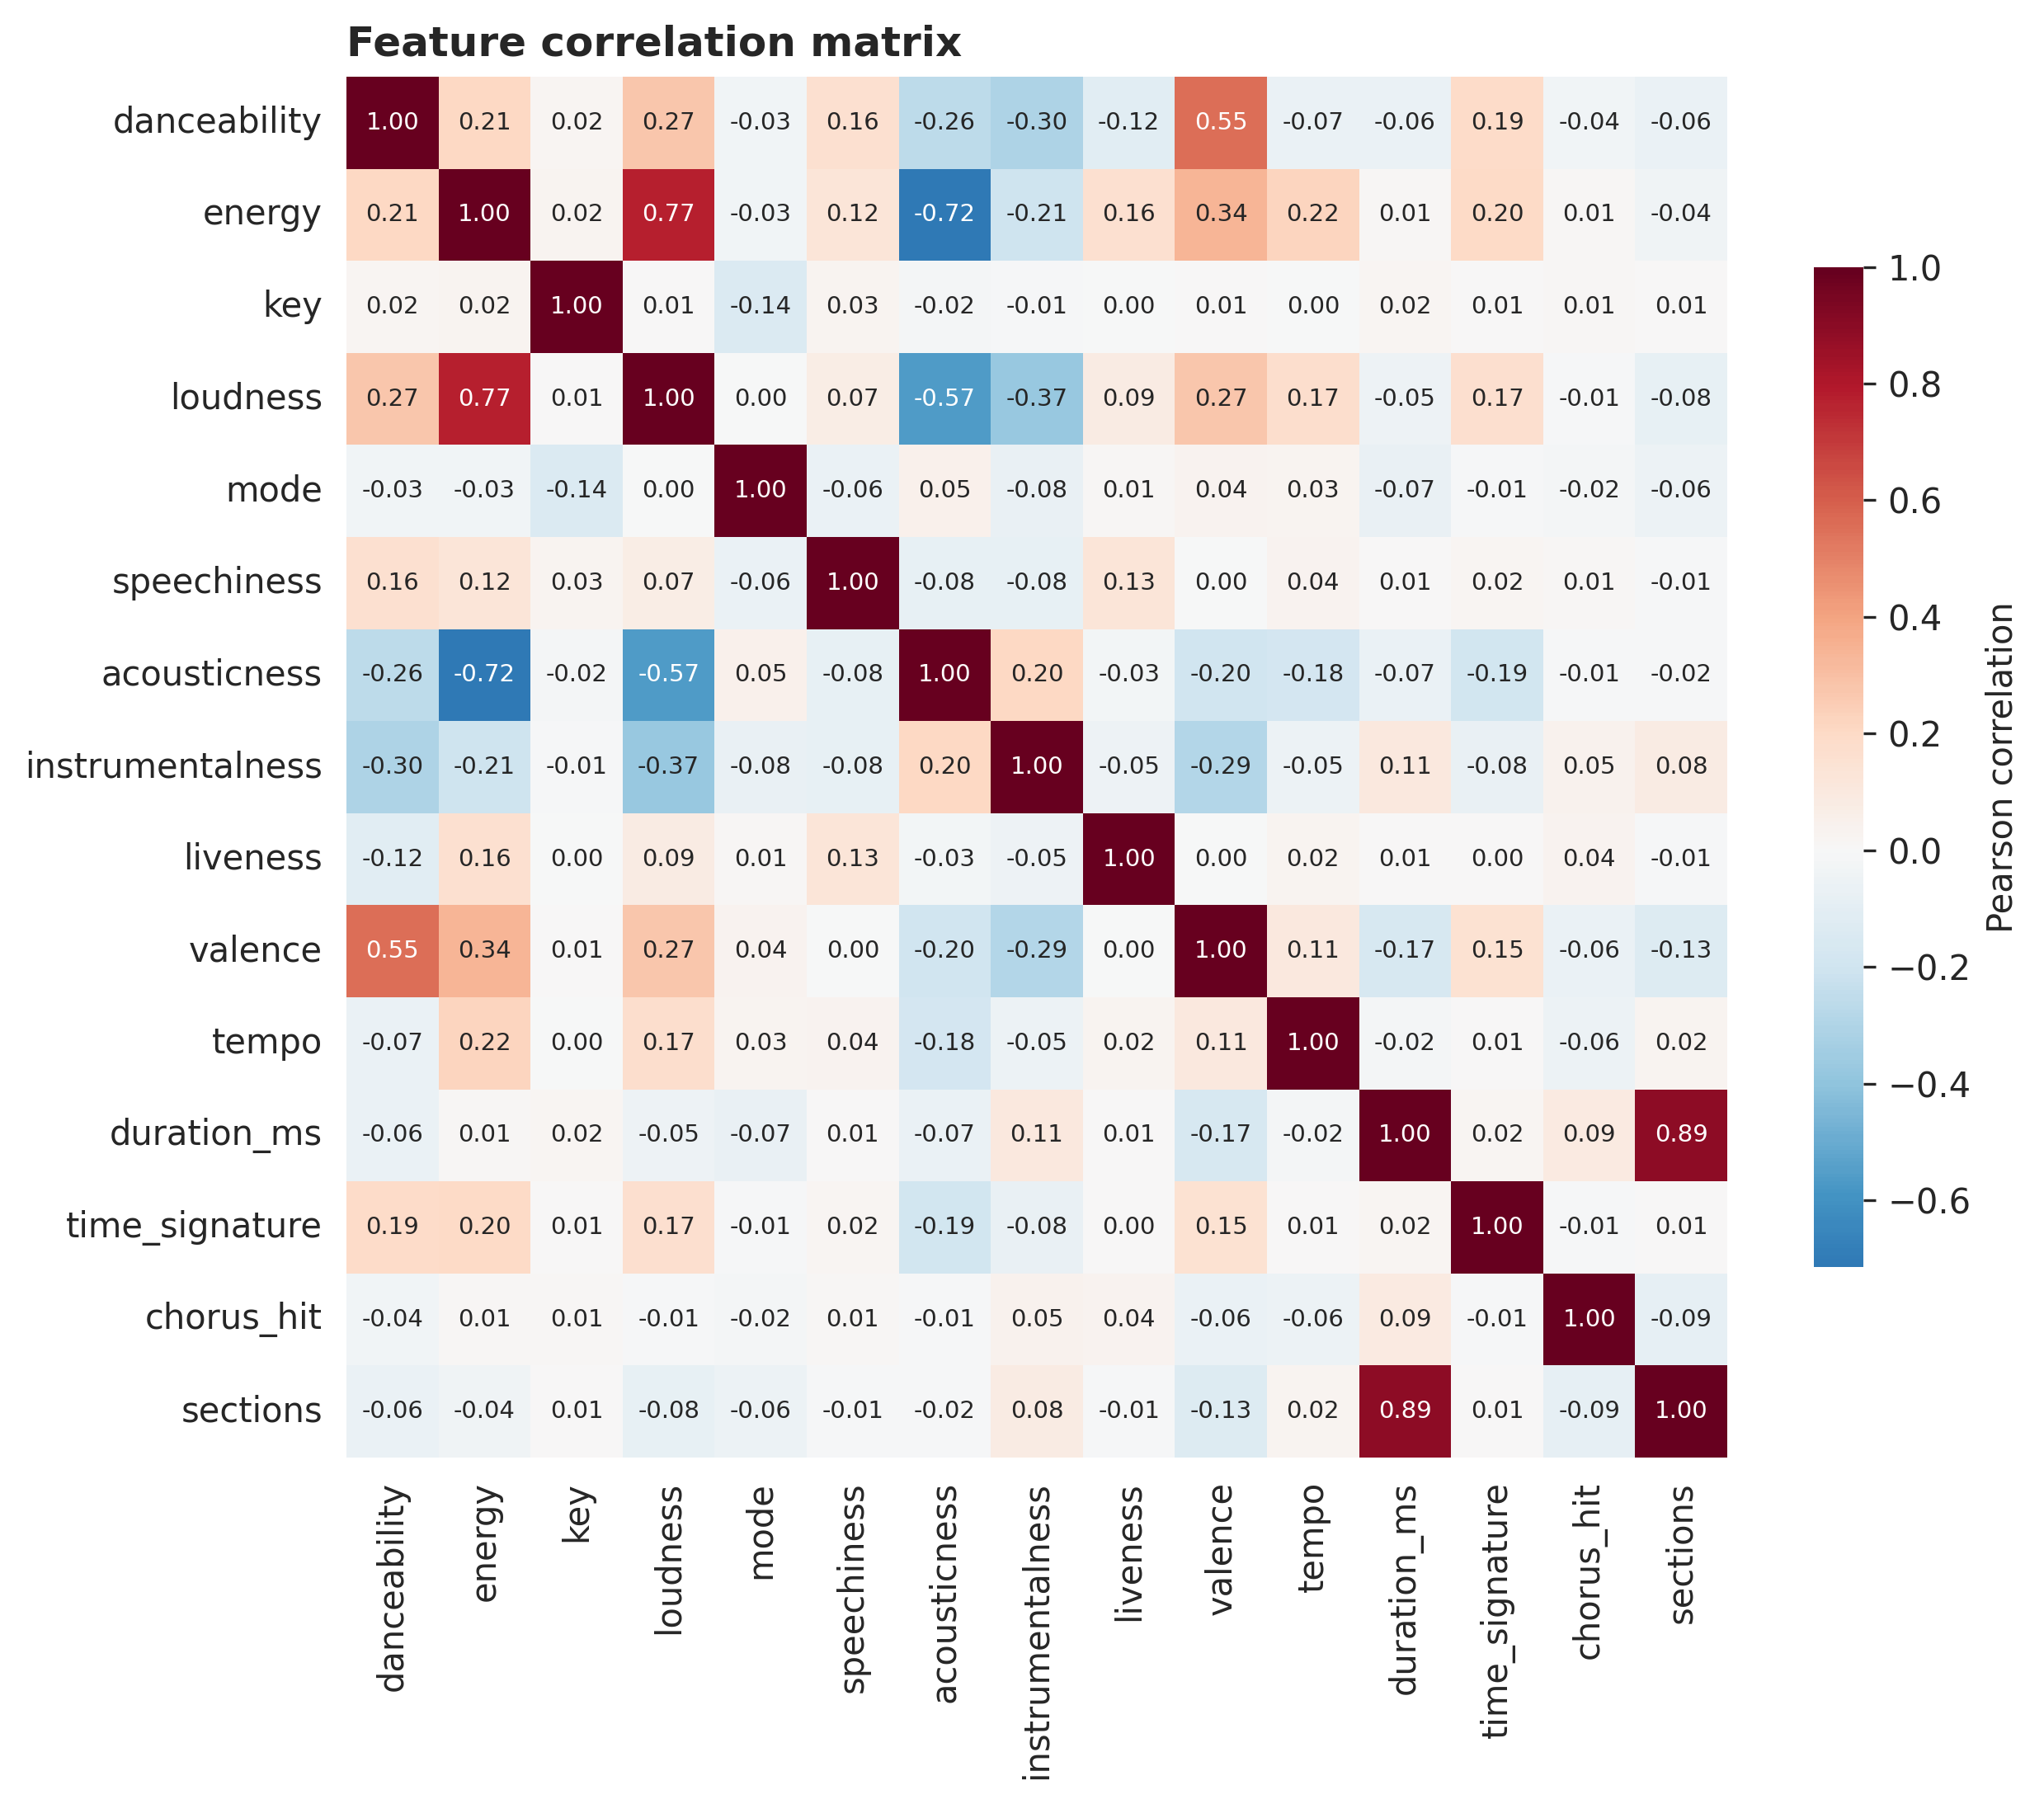

In [5]:
display(Image('../figures/eda3_correlation_heatmap.png'))

## Feature averages drift across eras
Loudness and energy rise while acousticness and instrumentalness fall — this motivates modelling each era separately.

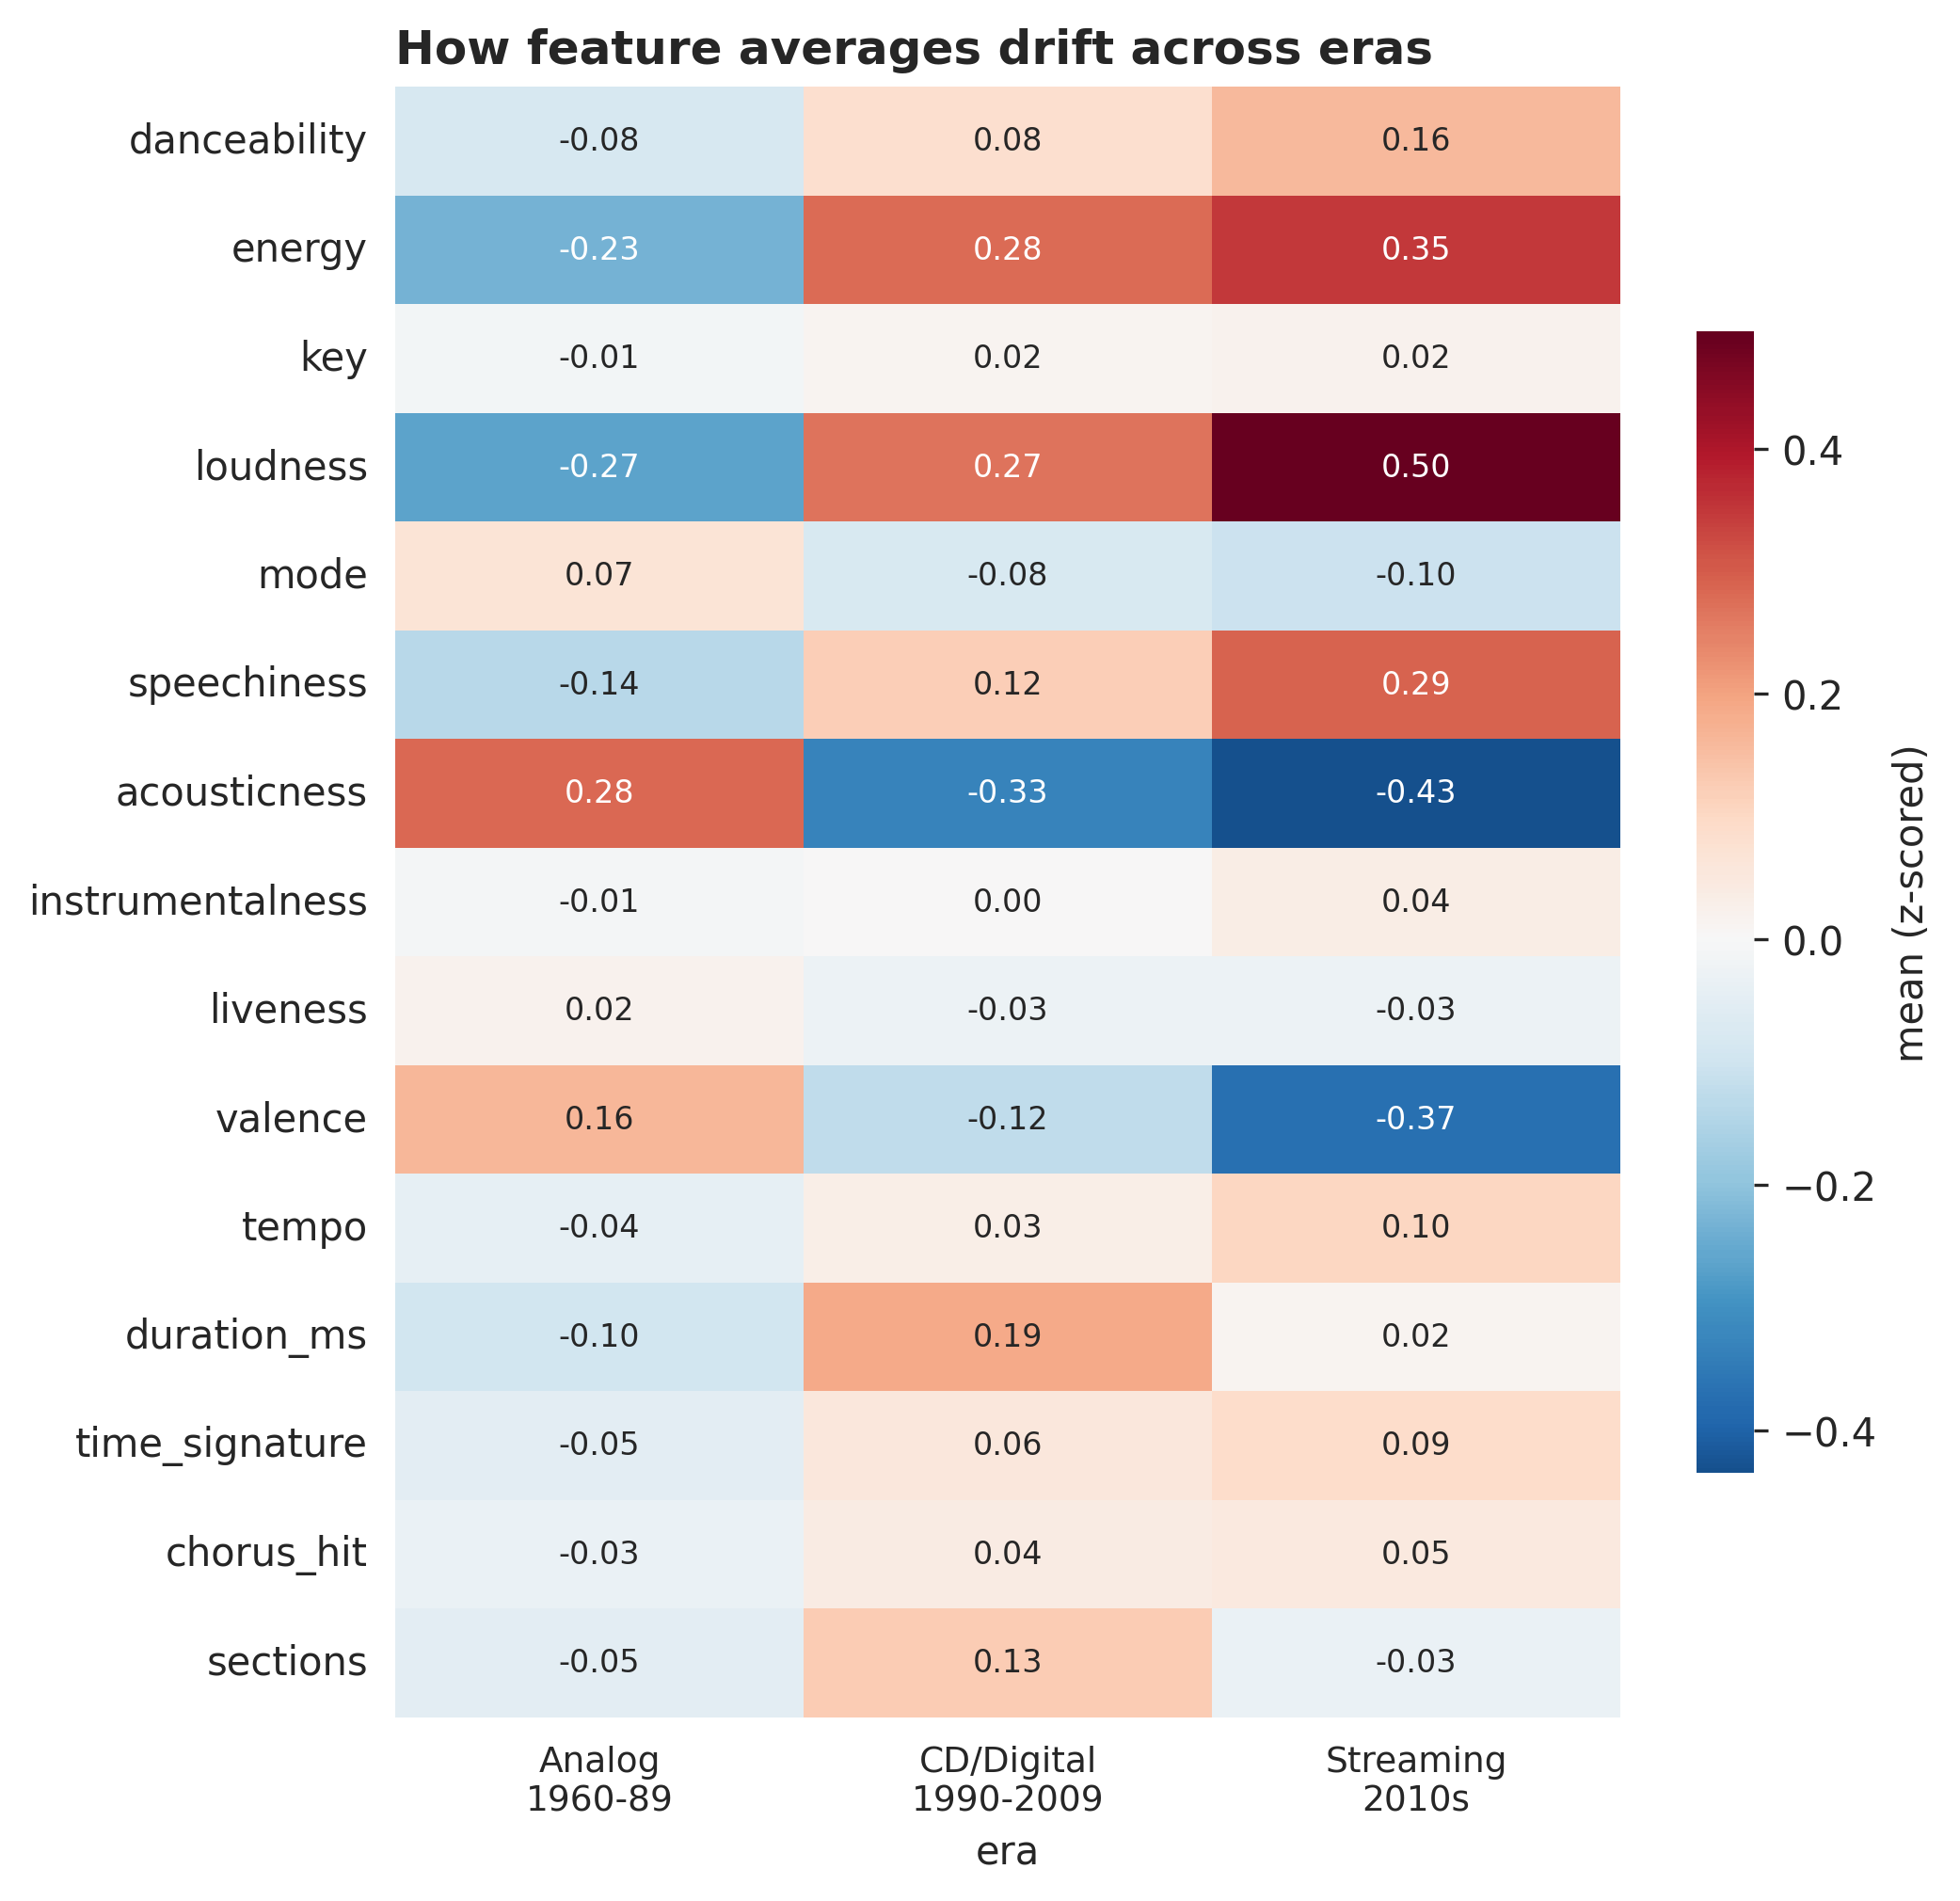

In [6]:
display(Image('../figures/eda4_feature_means_by_era.png'))